In [ ]:
!pip install ultralytics

import os
import shutil
import random
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

# ==============================
# 1. Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 2. Dataset Path
# ==============================
base_dir = "/content/drive/MyDrive/Smart_Food_Analyzer-Food_Images/Primary Categories"

if not os.path.exists(base_dir):
    raise FileNotFoundError(f"❌ Dataset not found at {base_dir}. Please check your shortcut path.")

print("✅ Found dataset at:", base_dir)

# ==============================
# 3. Prepare Dataset
# ==============================
dataset_dir = "/content/dataset_cls"
train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")

# reset old dataset if exists
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Parameters for balancing
min_images_per_class = 50     # drop classes with fewer images
max_images_per_class = 250    # cap very large classes to avoid imbalance

all_classes = {}

# helper: safe symlink creation
def safe_symlink(src, dst):
    try:
        if not os.path.exists(dst):
            os.symlink(src, dst)
    except FileExistsError:
        pass

# Traverse all categories → subcategories → nested food items
for primary_cat in os.listdir(base_dir):
    primary_path = os.path.join(base_dir, primary_cat)
    if not os.path.isdir(primary_path):
        continue

    for food_item in os.listdir(primary_path):
        food_item_path = os.path.join(primary_path, food_item)
        if not os.path.isdir(food_item_path):
            continue

        # if this folder still has sub-subfolders (like biryani), go deeper
        subfolders = [os.path.join(food_item_path, sf) for sf in os.listdir(food_item_path) if os.path.isdir(os.path.join(food_item_path, sf))]
        if subfolders:
            folders_to_collect = subfolders
        else:
            folders_to_collect = [food_item_path]

        for fpath in folders_to_collect:
            class_name = os.path.basename(fpath).strip().replace(" ", "_")
            images = [os.path.join(fpath, f) for f in os.listdir(fpath) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            if len(images) < min_images_per_class:
                print(f"⚠️ Skipping {class_name}, only {len(images)} images")
                continue

            # balance dataset: cap maximum
            if len(images) > max_images_per_class:
                images = random.sample(images, max_images_per_class)

            all_classes[class_name] = images

# ==============================
# 4. Train/Val Split (symlinks)
# ==============================
for class_name, images in all_classes.items():
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    for img in train_imgs:
        dst = os.path.join(train_dir, class_name, os.path.basename(img))
        safe_symlink(img, dst)

    for img in val_imgs:
        dst = os.path.join(val_dir, class_name, os.path.basename(img))
        safe_symlink(img, dst)

print(f"✅ Dataset ready with {len(all_classes)} classes")
for c, imgs in all_classes.items():
    print(f"{c}: {len(imgs)} images (train+val)")

# ==============================
# 5. Train Model
# ==============================
model = YOLO("yolov8m-cls.pt")

model.train(
    data=dataset_dir,
    epochs=50,
    imgsz=224,
    batch=32,
    lr0=0.001,
    optimizer="Adam",
    project="/content/drive/MyDrive/yolo_results",
    name="pakistani_food_cls",
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found dataset at: /content/drive/MyDrive/Smart_Food_Analyzer-Food_Images/Primary Categories
⚠️ Skipping Mutton_Karahi, only 0 images
⚠️ Skipping Nihari, only 0 images
⚠️ Skipping Qorma, only 0 images
⚠️ Skipping Paya, only 0 images
⚠️ Skipping Kunna, only 0 images
⚠️ Skipping Kofta_Curry, only 0 images
⚠️ Skipping Aloo_Bhujia, only 35 images
⚠️ Skipping Bhindi_Masala, only 38 images
⚠️ Skipping Tinda_Curry, only 0 images
⚠️ Skipping Mix_Sabzi, only 42 images
⚠️ Skipping palak_aloo, only 2 images
⚠️ Skipping palak_sabzi, only 3 images
⚠️ Skipping Aloo_Matar, only 38 images
⚠️ Skipping Kaddu_Sabzi, only 48 images
⚠️ Skipping Dal_Chana, only 0 images
⚠️ Skipping Masoor_Dal, only 0 images
⚠️ Skipping Dal_Makhni, only 0 images
⚠️ Skipping Dal_Mash, only 0 images
⚠️ Skipping Dal_Gosht, only 0 images
⚠️ Skipping Mixed_Dal_Fry, only 0 images
⚠️ Skipping Khichdi, on

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7982b8ed0f80>
curves: []
curves_results: []
fitness: 0.7673583328723907
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.6097366213798523, 'metrics/accuracy_top5': 0.9249800443649292, 'fitness': 0.7673583328723907}
save_dir: PosixPath('/content/drive/MyDrive/yolo_results/pakistani_food_cls2')
speed: {'preprocess': 0.07101079409954388, 'inference': 0.9201480542696411, 'loss': 0.00021214764390327704, 'postprocess': 0.0005813104531206325}
task: 'classify'
top1: 0.6097366213798523
top5: 0.9249800443649292

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive

image 1/1 /content/drive/MyDrive/zlpv-listing.jpg: 224x224 Roll_Paratha 0.97, Roti 0.02, Naan 0.00, Samosa 0.00, Beef_Tahari 0.00, 273.3ms
Speed: 141.4ms preprocess, 273.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


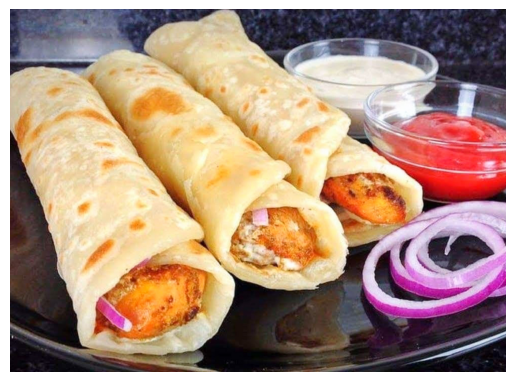

✅ Predicted: Roll Paratha (0.97)


In [ ]:
import matplotlib.pyplot as plt
import cv2

!pip install ultralytics

from ultralytics import YOLO
from google.colab import drive
drive.mount('/content/drive')

# 1. Load Trained Model (best weights)

model = YOLO("/content/drive/MyDrive/yolo_results/pakistani_food_cls2/weights/best.pt")


# 2. Test Image Path

img_path = "/content/drive/MyDrive/zlpv-listing.jpg"  # 🔁 change to your test image

# 3. Run Prediction

results = model.predict(source=img_path, save=False)

# 4. Show Image

img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 5. Print Predicted Label (Top-1)

for r in results:
    probs = r.probs.data.cpu().numpy()  # probability scores
    top1 = probs.argmax()               # best index
    class_name = model.names[top1]
    pretty_name = class_name.replace("_", " ")
    confidence = probs[top1]
    print(f"✅ Predicted: {pretty_name} ({confidence:.2f})")



image 1/1 /content/drive/MyDrive/images.jpeg: 224x224 Beef_Biryani 0.98, Mutton_Biryani 0.01, Chicken_Biryani 0.00, Beef_Tahari 0.00, Chicken_Tahari 0.00, 354.3ms
Speed: 5.5ms preprocess, 354.3ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)


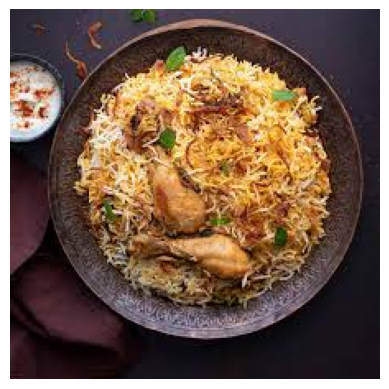

✅ Predicted: Beef Biryani (0.98)


In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_results/pakistani_food_cls2/weights/best.pt")


# 2. Test Image Path

img_path = "/content/drive/MyDrive/images.jpeg"  # 🔁 change to your test image

# 3. Run Prediction

results = model.predict(source=img_path, save=False)

# 4. Show Image

img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 5. Print Predicted Label (Top-1)

for r in results:
    probs = r.probs.data.cpu().numpy()  # probability scores
    top1 = probs.argmax()               # best index
    class_name = model.names[top1]
    pretty_name = class_name.replace("_", " ")
    confidence = probs[top1]
    print(f"✅ Predicted: {pretty_name} ({confidence:.2f})")



image 1/1 /content/drive/MyDrive/karahi.jpeg: 224x224 Haleem 0.74, Chicken_Karahi 0.20, Beef_Biryani 0.02, Mutton_Biryani 0.02, Beef_Tahari 0.01, 152.7ms
Speed: 2.7ms preprocess, 152.7ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


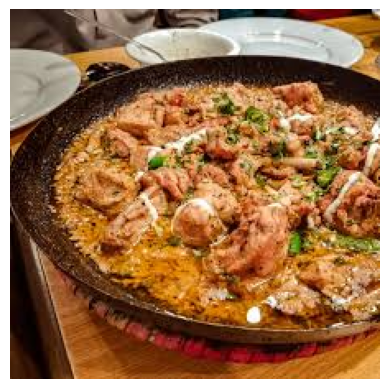

✅ Predicted: Haleem (0.74)


In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_results/pakistani_food_cls2/weights/best.pt")


# 2. Test Image Path

img_path = "/content/drive/MyDrive/karahi.jpeg"  # 🔁 change to your test image

# 3. Run Prediction

results = model.predict(source=img_path, save=False)

# 4. Show Image

img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 5. Print Predicted Label (Top-1)

for r in results:
    probs = r.probs.data.cpu().numpy()  # probability scores
    top1 = probs.argmax()               # best index
    class_name = model.names[top1]
    pretty_name = class_name.replace("_", " ")
    confidence = probs[top1]
    print(f"✅ Predicted: {pretty_name} ({confidence:.2f})")



image 1/1 /content/drive/MyDrive/aloo-gobi.jpg: 224x224 Vegetable_Tahari 0.85, Beef_Tahari 0.11, Chicken_Shorba 0.02, Chicken_Tahari 0.00, Aloo_Gobi 0.00, 587.3ms
Speed: 62.5ms preprocess, 587.3ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 224)


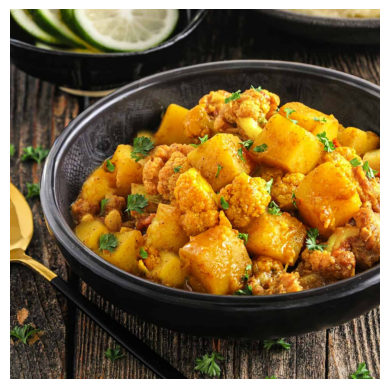

✅ Predicted: Vegetable Tahari (0.85)


In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_results/pakistani_food_cls2/weights/best.pt")


# 2. Test Image Path

img_path = "/content/drive/MyDrive/aloo-gobi.jpg"  # 🔁 change to your test image

# 3. Run Prediction

results = model.predict(source=img_path, save=False)

# 4. Show Image

img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 5. Print Predicted Label (Top-1)

for r in results:
    probs = r.probs.data.cpu().numpy()  # probability scores
    top1 = probs.argmax()               # best index
    class_name = model.names[top1]
    pretty_name = class_name.replace("_", " ")
    confidence = probs[top1]
    print(f"✅ Predicted: {pretty_name} ({confidence:.2f})")



image 1/1 /content/drive/MyDrive/samosa.jpg: 224x224 Samosa 1.00, Chicken_Tahari 0.00, side_view 0.00, Bhuna_Gosht 0.00, Chicken_Biryani 0.00, 676.8ms
Speed: 31.3ms preprocess, 676.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


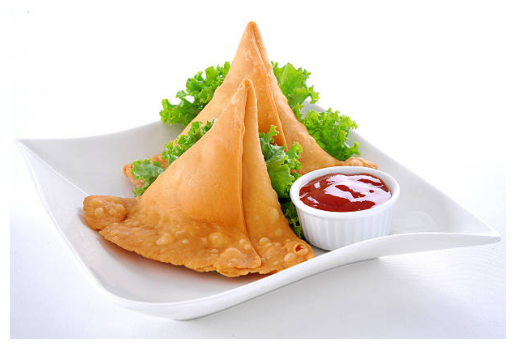

✅ Predicted: Samosa (1.00)


In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_results/pakistani_food_cls2/weights/best.pt")


# 2. Test Image Path

img_path = "/content/drive/MyDrive/samosa.jpg"  # 🔁 change to your test image

# 3. Run Prediction

results = model.predict(source=img_path, save=False)

# 4. Show Image

img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 5. Print Predicted Label (Top-1)

for r in results:
    probs = r.probs.data.cpu().numpy()  # probability scores
    top1 = probs.argmax()               # best index
    class_name = model.names[top1]
    pretty_name = class_name.replace("_", " ")
    confidence = probs[top1]
    print(f"✅ Predicted: {pretty_name} ({confidence:.2f})")



image 1/1 /content/drive/MyDrive/samosa-2.jpeg: 224x224 Samosa 1.00, Roti 0.00, Roll_Paratha 0.00, Gulab_Jamun 0.00, Chicken_Shorba 0.00, 128.5ms
Speed: 4.2ms preprocess, 128.5ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


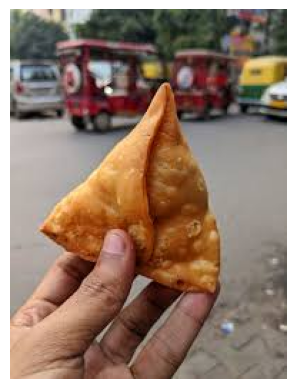

✅ Predicted: Samosa (1.00)


In [ ]:
model = YOLO("/content/drive/MyDrive/yolo_results/pakistani_food_cls2/weights/best.pt")


# 2. Test Image Path

img_path = "/content/drive/MyDrive/samosa-2.jpeg"  # 🔁 change to your test image

# 3. Run Prediction

results = model.predict(source=img_path, save=False)

# 4. Show Image

img = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# 5. Print Predicted Label (Top-1)

for r in results:
    probs = r.probs.data.cpu().numpy()  # probability scores
    top1 = probs.argmax()               # best index
    class_name = model.names[top1]
    pretty_name = class_name.replace("_", " ")
    confidence = probs[top1]
    print(f"✅ Predicted: {pretty_name} ({confidence:.2f})")
